In [7]:
from google.cloud import bigquery
import pandas as pd
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


In [21]:
# Set your GCP project explicitly to avoid ADC surprises in notebooks.
PROJECT_ID = "mimic-pruebas"  # <-- change to your GCP project if needed

# Create a BigQuery client
client = bigquery.Client(project=PROJECT_ID)

# Base dataset/table prefixes for MIMIC-IV v3.1 on BigQuery
DERIVED = "physionet-data.mimiciv_3_1_derived"
HOSP = "physionet-data.mimiciv_3_1_hosp"
ICU  = "physionet-data.mimiciv_3_1_icu"

In [5]:
client = bigquery.Client(project=PROJECT_ID)

sql_counts = f"""
WITH base AS (
  SELECT subject_id, hadm_id FROM `{HOSP}.admissions`
),
icu_adm AS (
  SELECT DISTINCT hadm_id FROM `{ICU}.icustays`
),
infected_micro AS (
  SELECT DISTINCT a.subject_id, a.hadm_id
  FROM `{HOSP}.microbiologyevents` AS me
  JOIN `{HOSP}.admissions` AS a
    ON me.hadm_id = a.hadm_id
  WHERE (
    LOWER(COALESCE(me.interpretation, '')) LIKE '%positive%'
    OR me.org_name IS NOT NULL
  )
  AND me.charttime BETWEEN a.admittime AND a.dischtime
)

SELECT
  COUNT(DISTINCT b.subject_id) AS total_patients,
  COUNT(DISTINCT b.hadm_id) AS total_admissions,
  COUNT(DISTINCT i.hadm_id) AS admissions_with_icu,
  COUNT(DISTINCT inf.subject_id) AS infected_patients,
  COUNT(DISTINCT inf.hadm_id) AS infected_admissions
FROM base AS b
LEFT JOIN icu_adm AS i
  ON b.hadm_id = i.hadm_id
LEFT JOIN infected_micro AS inf
  ON b.hadm_id = inf.hadm_id;
"""

df_counts = client.query(sql_counts).result().to_dataframe()
display(df_counts)

E0000 00:00:1760593467.956229   17459 alts_credentials.cc:93] ALTS creds ignored. Not running on GCP and untrusted ALTS is not enabled.


,total_patients,total_admissions,admissions_with_icu,infected_patients,infected_admissions
0,223452,546028,85242,43191,62768


E0000 00:00:1760593589.881893   17459 alts_credentials.cc:93] ALTS creds ignored. Not running on GCP and untrusted ALTS is not enabled.


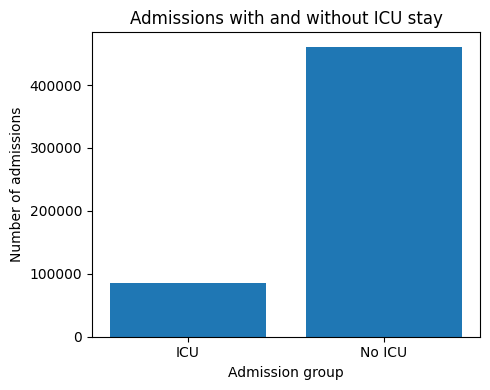

In [8]:
# --- Admissions with and without ICU stay ------------------------------------
sql_icu = f"""
SELECT
  CASE WHEN icu.hadm_id IS NOT NULL THEN 'ICU' ELSE 'No ICU' END AS group_label,
  COUNT(DISTINCT a.hadm_id) AS n_admissions,
  COUNT(DISTINCT a.subject_id) AS n_patients
FROM `{HOSP}.admissions` AS a
LEFT JOIN `{ICU}.icustays` AS icu
  ON a.hadm_id = icu.hadm_id
GROUP BY group_label
ORDER BY group_label;
"""
df_icu = client.query(sql_icu).result().to_dataframe()

plt.figure(figsize=(5, 4))
plt.bar(df_icu["group_label"], df_icu["n_admissions"])
plt.title("Admissions with and without ICU stay")
plt.ylabel("Number of admissions")
plt.xlabel("Admission group")
plt.tight_layout()
plt.show()

E0000 00:00:1760593795.403186   17459 alts_credentials.cc:93] ALTS creds ignored. Not running on GCP and untrusted ALTS is not enabled.


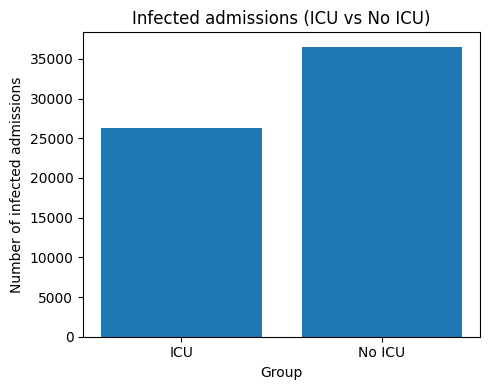

In [10]:
# --- Infected admissions/patients by ICU vs No ICU ---------------------------
sql_inf_icu = f"""
WITH infected_hadm AS (
  SELECT DISTINCT a.subject_id, me.hadm_id
  FROM `{HOSP}.microbiologyevents` AS me
  JOIN `{HOSP}.admissions` AS a
    ON me.hadm_id = a.hadm_id
  WHERE (
    LOWER(COALESCE(me.interpretation, '')) LIKE '%positive%'
    OR me.org_name IS NOT NULL
  )
  AND me.charttime BETWEEN a.admittime AND a.dischtime
)
SELECT
  CASE WHEN icu.hadm_id IS NOT NULL THEN 'ICU' ELSE 'No ICU' END AS group_label,
  COUNT(DISTINCT inf.hadm_id) AS infected_admissions,
  COUNT(DISTINCT inf.subject_id) AS infected_patients
FROM infected_hadm AS inf
LEFT JOIN `{ICU}.icustays` AS icu
  ON inf.hadm_id = icu.hadm_id
GROUP BY group_label
ORDER BY group_label;
"""

df_inf_icu = client.query(sql_inf_icu).result().to_dataframe()

plt.figure(figsize=(5, 4))
plt.bar(df_inf_icu["group_label"], df_inf_icu["infected_admissions"])
plt.title("Infected admissions (ICU vs No ICU)")
plt.ylabel("Number of infected admissions")
plt.xlabel("Group")
plt.tight_layout()
plt.show()

In [16]:
# --- Corrected ICU infection overlap query -----------------------------------
sql_infection_icu_fixed = f"""
WITH
infected_hadm AS (
  SELECT DISTINCT a.subject_id, a.hadm_id
  FROM `{HOSP}.microbiologyevents` AS me
  JOIN `{HOSP}.admissions` AS a
    ON me.hadm_id = a.hadm_id
  WHERE (
    LOWER(COALESCE(me.interpretation, '')) LIKE '%positive%'
    OR me.org_name IS NOT NULL
  )
  AND me.charttime BETWEEN a.admittime AND a.dischtime
),
icu_adm AS (
  SELECT DISTINCT subject_id, hadm_id
  FROM `{ICU}.icustays`
)

SELECT
  -- unique patients who ever had ICU stay
  COUNT(DISTINCT icu.subject_id) AS total_icu_patients,
  -- unique patients who ever had infection (anywhere in hospital)
  COUNT(DISTINCT inf.subject_id) AS infected_patients,
  -- intersection: patients who appear in both sets
  COUNT(DISTINCT CASE WHEN inf.subject_id IS NOT NULL THEN icu.subject_id END)
    AS infected_icu_patients
FROM icu_adm AS icu
FULL OUTER JOIN infected_hadm AS inf
  ON icu.subject_id = inf.subject_id;
"""

df_infection_icu_fixed = client.query(sql_infection_icu_fixed).result().to_dataframe()
display(df_infection_icu_fixed)


E0000 00:00:1760594607.761478   17459 alts_credentials.cc:93] ALTS creds ignored. Not running on GCP and untrusted ALTS is not enabled.


,total_icu_patients,infected_patients,infected_icu_patients
0,65366,43191,26543


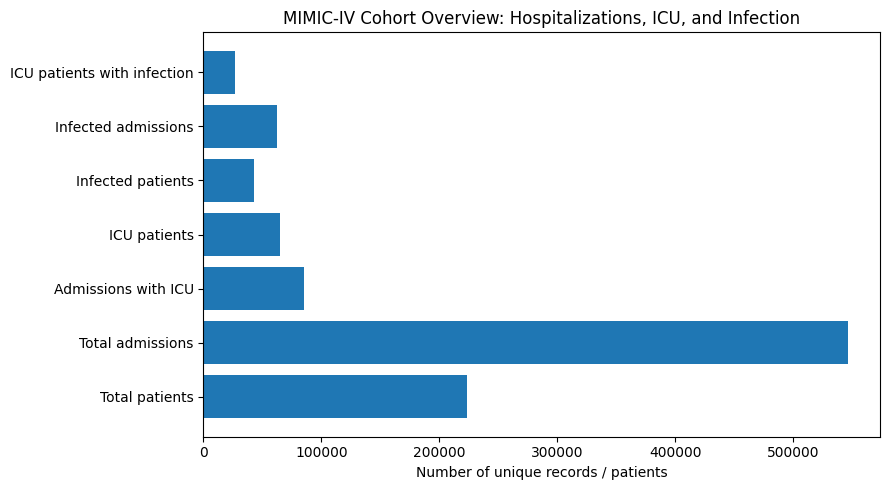

,Metric,Count
0,Total patients,223452
1,Total admissions,546028
2,Admissions with ICU,85242
3,ICU patients,65366
4,Infected patients,43191
5,Infected admissions,62768
6,ICU patients with infection,26543


Proportion of admissions with ICU stay:           15.61%
Proportion of patients with infection:            19.33%
Proportion of ICU patients with infection:        40.61%
Proportion of infected patients admitted to ICU:  61.45%


In [17]:
# --- Final summary overview -------------------------------------------------
# Combines previous metrics (df_counts + df_infection_icu_fixed)
# to visualize the overall cohort: total, hospital, ICU, and infection overlap.

# Extract key counts from existing DataFrames
total_patients          = int(df_counts["total_patients"].iloc[0])
total_admissions        = int(df_counts["total_admissions"].iloc[0])
admissions_with_icu     = int(df_counts["admissions_with_icu"].iloc[0])
infected_patients       = int(df_counts["infected_patients"].iloc[0])
infected_admissions     = int(df_counts["infected_admissions"].iloc[0])
icu_patients            = int(df_infection_icu_fixed["total_icu_patients"].iloc[0])
infected_icu_patients   = int(df_infection_icu_fixed["infected_icu_patients"].iloc[0])

# Build summary table
summary_df = pd.DataFrame({
    "Metric": [
        "Total patients",
        "Total admissions",
        "Admissions with ICU",
        "ICU patients",
        "Infected patients",
        "Infected admissions",
        "ICU patients with infection"
    ],
    "Count": [
        total_patients,
        total_admissions,
        admissions_with_icu,
        icu_patients,
        infected_patients,
        infected_admissions,
        infected_icu_patients
    ]
})

# --- Plot -------------------------------------------------------------------
plt.figure(figsize=(9, 5))
plt.barh(summary_df["Metric"], summary_df["Count"])
plt.title("MIMIC-IV Cohort Overview: Hospitalizations, ICU, and Infection")
plt.xlabel("Number of unique records / patients")
plt.tight_layout()
plt.show()

display(summary_df)

# --- Proportions for interpretability ---------------------------------------
print(f"Proportion of admissions with ICU stay:           {admissions_with_icu / total_admissions:.2%}")
print(f"Proportion of patients with infection:            {infected_patients / total_patients:.2%}")
print(f"Proportion of ICU patients with infection:        {infected_icu_patients / icu_patients:.2%}")
print(f"Proportion of infected patients admitted to ICU:  {infected_icu_patients / infected_patients:.2%}")

In [29]:
# NOTE:
# This analysis is restricted to patients admitted to the Intensive Care Unit (ICU).
# Demographic variables such as age and sex are only available in the `mimiciv_derived.icustay_detail` table,
# which means that non-ICU hospital admissions cannot be included in this part of the analysis.
# Access to `mimiciv_core.patients` would be required to extend these variables to the full hospital population.

In [24]:
# --- Demographics in ICU: sex, admission_age, and infection ------------------
# Uses physionet-data.mimiciv_3_1_derived.icustay_detail:
#   - gender
#   - admission_age
# Infection definition: positive microbiology OR non-null org_name within the admission window.

sql_icu_demo = f"""
WITH infected_hadm AS (
  SELECT DISTINCT a.hadm_id
  FROM `{HOSP}.microbiologyevents` me
  JOIN `{HOSP}.admissions` a
    ON me.hadm_id = a.hadm_id
  WHERE (
    LOWER(COALESCE(me.interpretation, '')) LIKE '%positive%'
    OR me.org_name IS NOT NULL
  )
  AND me.charttime BETWEEN a.admittime AND a.dischtime
)
SELECT
  d.subject_id,
  d.hadm_id,
  d.stay_id,
  d.gender,
  SAFE_CAST(d.admission_age AS FLOAT64) AS admission_age,
  CASE WHEN inf.hadm_id IS NOT NULL THEN 'Infected' ELSE 'Not infected' END AS infection_status,
  d.hospital_expire_flag,
  d.los_icu
FROM `{DERIVED}.icustay_detail` d
LEFT JOIN infected_hadm inf
  ON d.hadm_id = inf.hadm_id
"""

df_icu_demo = client.query(sql_icu_demo).result().to_dataframe()

# --- Basic cleaning -----------------------------------------------------------
# Drop missing/invalid ages; clip at 0..120 just in case
df_icu_demo = df_icu_demo.dropna(subset=["admission_age", "gender"])
df_icu_demo = df_icu_demo[(df_icu_demo["admission_age"] >= 0) & (df_icu_demo["admission_age"] <= 120)]

print(f"ICU stays: {len(df_icu_demo):,} | Unique patients: {df_icu_demo['subject_id'].nunique():,}")
display(df_icu_demo.head())

E0000 00:00:1760597029.632384   17459 alts_credentials.cc:93] ALTS creds ignored. Not running on GCP and untrusted ALTS is not enabled.


ICU stays: 94,458 | Unique patients: 65,366


,subject_id,hadm_id,stay_id,gender,admission_age,infection_status,hospital_expire_flag,los_icu
0,10580523,22781129,32545229,F,23.0,Infected,0,2.750000000
1,11544655,27608012,32486077,F,84.0,Infected,0,4.250000000
2,10810063,20573862,32154233,F,22.0,Infected,0,4.790000000
3,17256511,20577555,36222763,F,70.0,Infected,0,1.130000000
4,17369878,21302475,39916109,M,57.0,Infected,0,27.290000000


<Figure size 600x400 with 0 Axes>

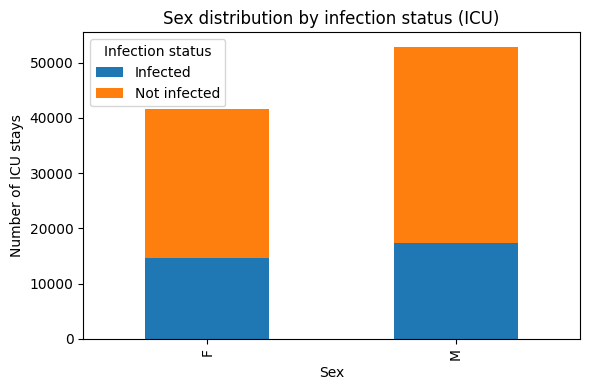

,gender,n_stays,infected_stays,infected_rate
0,F,41583,14603,0.351177
1,M,52875,17324,0.327641


In [25]:
# --- Sex distribution by infection (ICU cohort) ------------------------------
sex_counts = (
    df_icu_demo.groupby(["gender", "infection_status"])
    .size()
    .reset_index(name="count")
)

plt.figure(figsize=(6,4))
(
    sex_counts.pivot(index="gender", columns="infection_status", values="count")
    .plot(kind="bar", stacked=True, figsize=(6,4))
)
plt.title("Sex distribution by infection status (ICU)")
plt.ylabel("Number of ICU stays")
plt.xlabel("Sex")
plt.legend(title="Infection status")
plt.tight_layout()
plt.show()

sex_summary = (
    df_icu_demo.groupby("gender")
    .agg(n_stays=("stay_id","count"),
         infected_stays=("infection_status", lambda s: (s=="Infected").sum()))
    .reset_index()
)
sex_summary["infected_rate"] = sex_summary["infected_stays"] / sex_summary["n_stays"]
display(sex_summary)

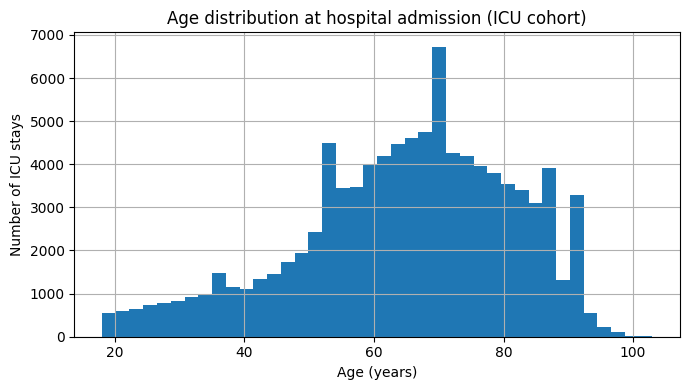

,overall,Infected,Not infected
count,94458.000000,31927.000000,62531.000000
mean,64.780527,65.586839,64.368841
std,16.739041,16.001782,17.088679
min,18.000000,18.000000,18.000000
25%,55.000000,56.000000,54.000000
50%,66.000000,67.000000,66.000000
75%,77.000000,78.000000,77.000000
max,103.000000,103.000000,103.000000


In [26]:
# --- Age distribution (histogram) --------------------------------------------
plt.figure(figsize=(7,4))
df_icu_demo["admission_age"].hist(bins=40)
plt.title("Age distribution at hospital admission (ICU cohort)")
plt.xlabel("Age (years)")
plt.ylabel("Number of ICU stays")
plt.tight_layout()
plt.show()

# Summary stats overall and by infection
age_overall = df_icu_demo["admission_age"].describe().to_frame(name="overall")
age_by_infection = (
    df_icu_demo.groupby("infection_status")["admission_age"]
    .describe()
    .T
)
display(pd.concat([age_overall, age_by_infection], axis=1))

In [27]:
# --- Mean/median age by infection and (optionally) mortality -----------------
summary_age = (
    df_icu_demo.groupby("infection_status")["admission_age"]
    .agg(count="count", mean="mean", median="median")
    .reset_index()
)
display(summary_age)

# Optional: compare age by infection within survivors vs non-survivors
if "hospital_expire_flag" in df_icu_demo.columns:
    age_mort = (
        df_icu_demo.groupby(["hospital_expire_flag","infection_status"])["admission_age"]
        .agg(count="count", mean="mean", median="median")
        .reset_index()
        .sort_values(["hospital_expire_flag","infection_status"])
    )
    display(age_mort)

,infection_status,count,mean,median
0,Infected,31927,65.586839,67.0
1,Not infected,62531,64.368841,66.0


,hospital_expire_flag,infection_status,count,mean,median
0,0,Infected,25682,64.754069,66.0
1,0,Not infected,57426,63.702295,65.0
2,1,Infected,6245,69.011529,70.0
3,1,Not infected,5105,71.866797,75.0


/tmp/ipykernel_17459/3898193366.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_icu_demo.groupby("age_group")


,age_group,n_stays,infected_stays,infected_rate
0,<18,0,0,NaN
1,18–39,8653,2436,0.281521
2,40–64,34075,11357,0.333294
3,65+,51730,18134,0.350551


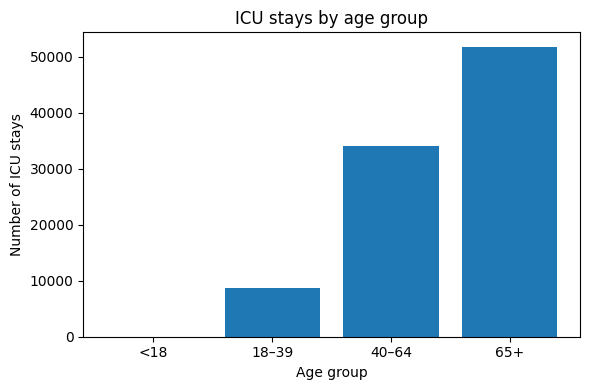

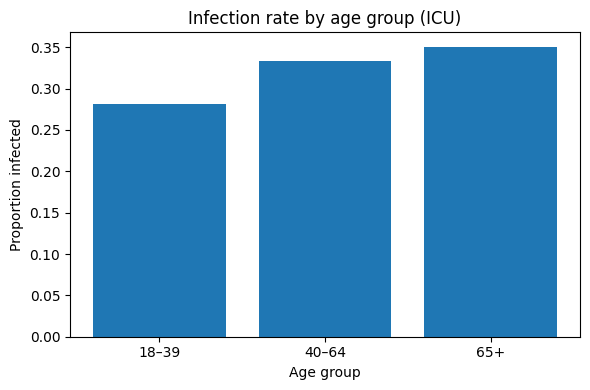

In [28]:
# --- Age groups and infection rate by group ----------------------------------
# Create 4 standard age bins for clinical reporting
bins = [0, 18, 40, 65, 120]
labels = ["<18", "18–39", "40–64", "65+"]
df_icu_demo["age_group"] = pd.cut(df_icu_demo["admission_age"], bins=bins, labels=labels, right=False)

agegrp = (
    df_icu_demo.groupby("age_group")
    .agg(n_stays=("stay_id","count"),
         infected_stays=("infection_status", lambda s: (s=="Infected").sum()))
    .reset_index()
)
agegrp["infected_rate"] = agegrp["infected_stays"] / agegrp["n_stays"]
display(agegrp)

plt.figure(figsize=(6,4))
plt.bar(agegrp["age_group"].astype(str), agegrp["n_stays"])
plt.title("ICU stays by age group")
plt.xlabel("Age group")
plt.ylabel("Number of ICU stays")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,4))
plt.bar(agegrp["age_group"].astype(str), agegrp["infected_rate"])
plt.title("Infection rate by age group (ICU)")
plt.xlabel("Age group")
plt.ylabel("Proportion infected")
plt.tight_layout()
plt.show()